In [ ]:
import io
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.decomposition import PCA
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error,mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor as DTR
from sklearn.ensemble import RandomForestRegressor as RFR
from sklearn.svm import SVR

!pip install mlxtend==0.22.0
from mlxtend.feature_selection import SequentialFeatureSelector

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 14.5 MB/s eta 0:00:00
  Attempting uninstall: mlxtend
    Found existing installation: mlxtend 0.23.3
    Uninstalling mlxtend-0.23.3:
      Successfully uninstalled mlxtend-0.23.3


In [ ]:
data = pd.read_csv('/content/drive/MyDrive/all_seasons.csv')
data.head()

,Unnamed: 0,player_name,team_abbreviation,age,player_height,player_weight,college,country,draft_year,draft_round,...,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct,season
0,0,Randy Livingston,HOU,22.0,193.04,94.800728,Louisiana State,USA,1996,2,...,3.9,1.5,2.4,0.3,0.042,0.071,0.169,0.487,0.248,1996-97
1,1,Gaylon Nickerson,WAS,28.0,190.50,86.182480,Northwestern Oklahoma,USA,1994,2,...,3.8,1.3,0.3,8.9,0.030,0.111,0.174,0.497,0.043,1996-97
2,2,George Lynch,VAN,26.0,203.20,103.418976,North Carolina,USA,1993,1,...,8.3,6.4,1.9,-8.2,0.106,0.185,0.175,0.512,0.125,1996-97
3,3,George McCloud,LAL,30.0,203.20,102.058200,Florida State,USA,1989,1,...,10.2,2.8,1.7,-2.7,0.027,0.111,0.206,0.527,0.125,1996-97
4,4,George Zidek,DEN,23.0,213.36,119.748288,UCLA,USA,1995,1,...,2.8,1.7,0.3,-14.1,0.102,0.169,0.195,0.500,0.064,1996-97


In [ ]:
data['draft_year'] = pd.to_numeric(data['draft_year'], errors='coerce').fillna(0).astype(int)
data['draft_round'] = pd.to_numeric(data['draft_round'], errors='coerce').fillna(0).astype(int)
data['draft_number'] = pd.to_numeric(data['draft_number'], errors='coerce').fillna(0).astype(int)
data.drop(['Unnamed: 0','player_name'],axis=1,inplace=True)
data = data[~(data == 0).any(axis=1)]
data.reset_index(drop=True, inplace=True)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9952 entries, 0 to 9951
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   team_abbreviation  9952 non-null   object 
 1   age                9952 non-null   float64
 2   player_height      9952 non-null   float64
 3   player_weight      9952 non-null   float64
 4   college            8394 non-null   object 
 5   country            9952 non-null   object 
 6   draft_year         9952 non-null   int64  
 7   draft_round        9952 non-null   int64  
 8   draft_number       9952 non-null   int64  
 9   gp                 9952 non-null   int64  
 10  pts                9952 non-null   float64
 11  reb                9952 non-null   float64
 12  ast                9952 non-null   float64
 13  net_rating         9952 non-null   float64
 14  oreb_pct           9952 non-null   float64
 15  dreb_pct           9952 non-null   float64
 16  usg_pct            9952 

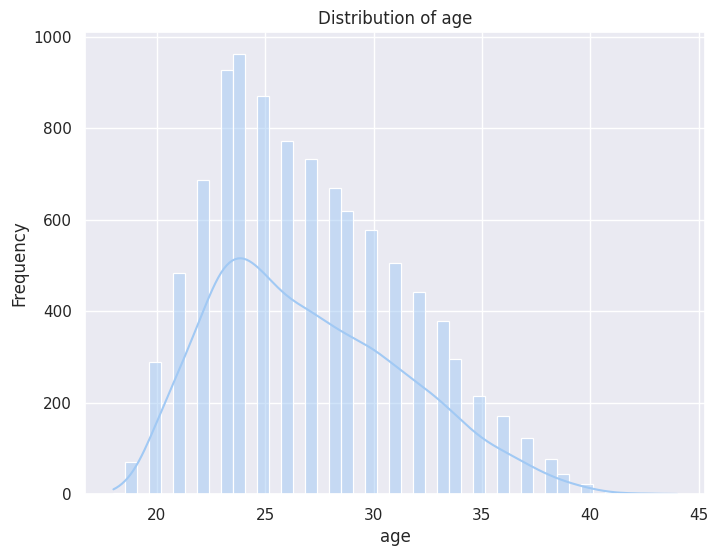

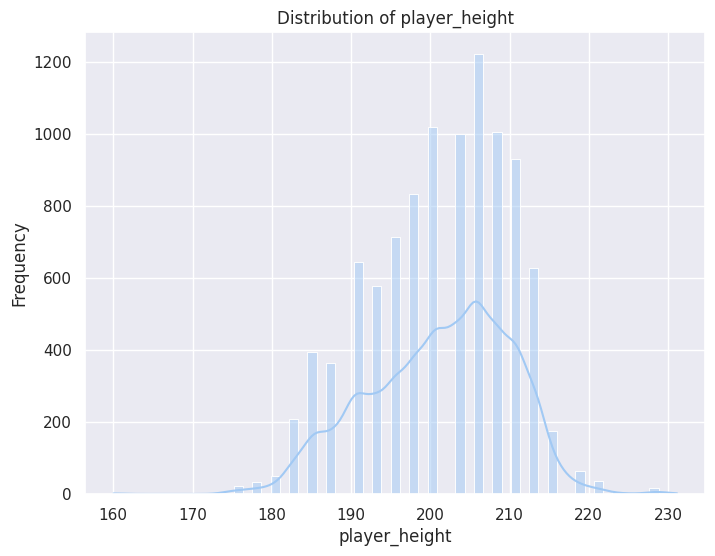

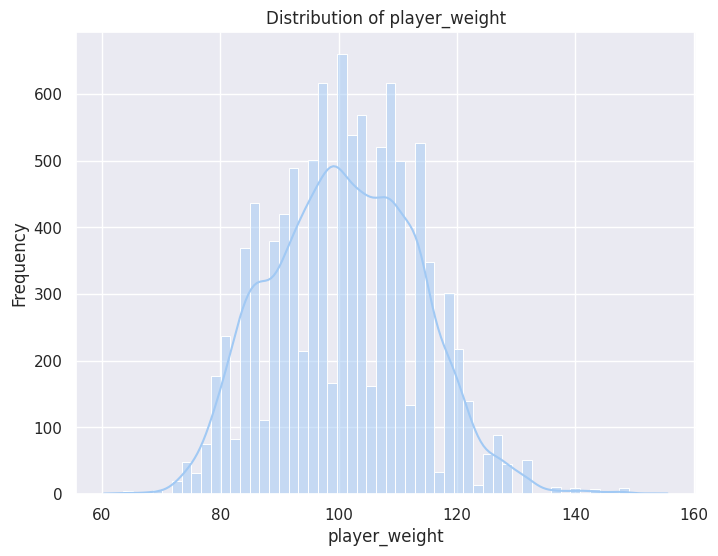

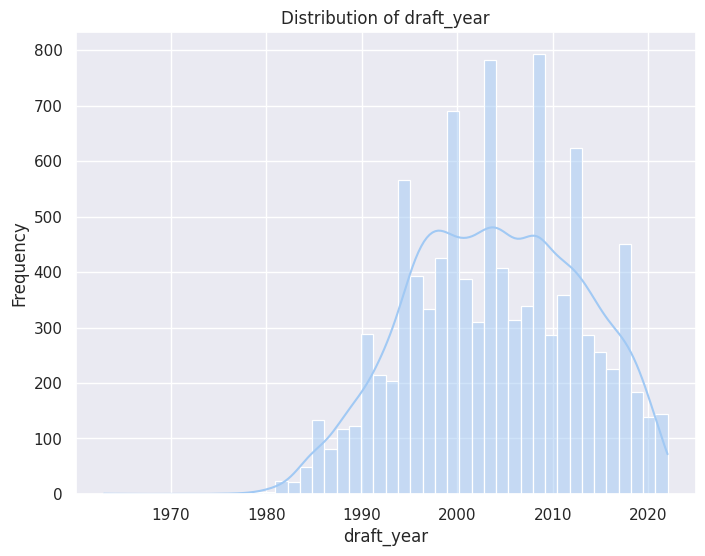

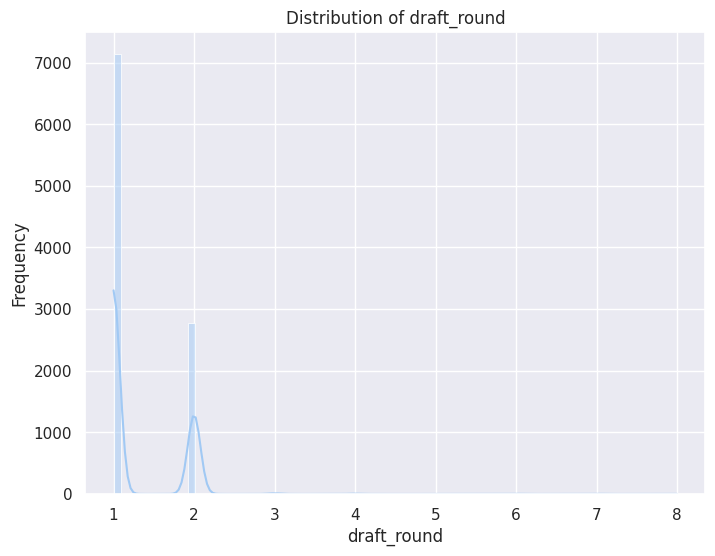

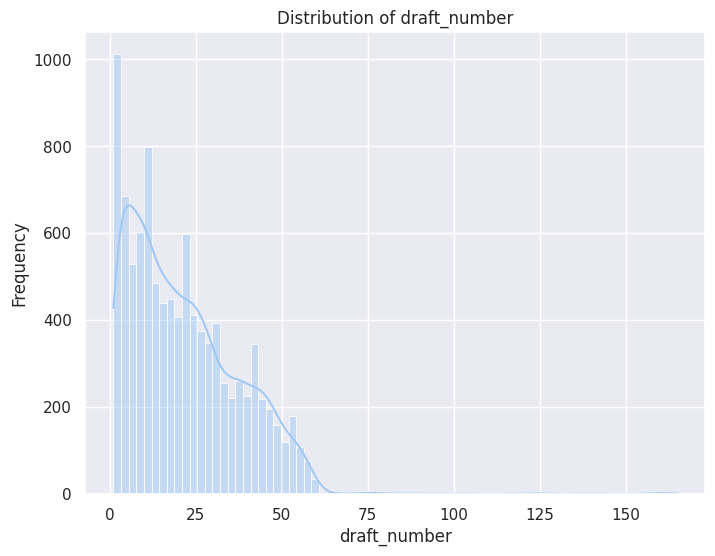

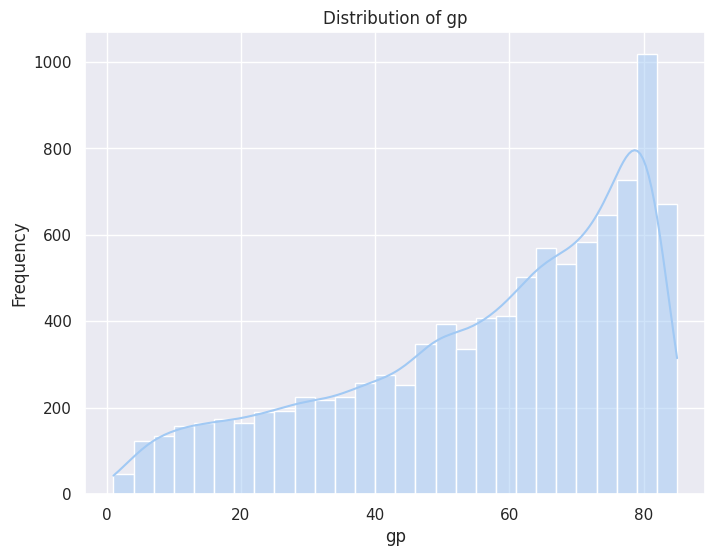

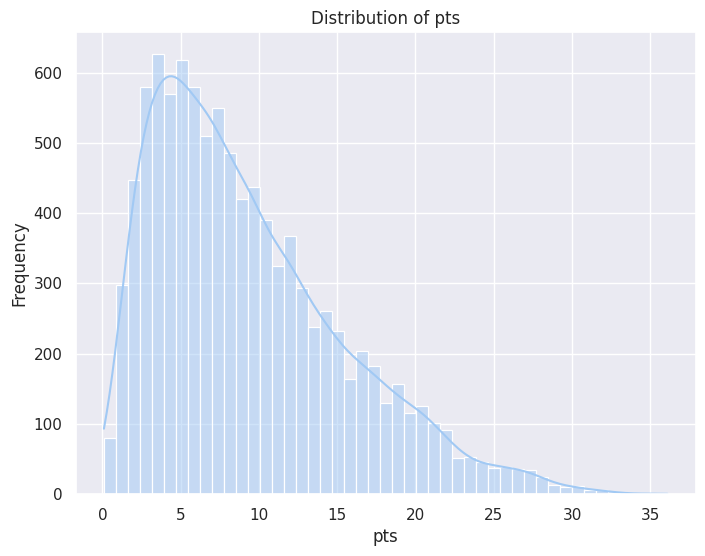

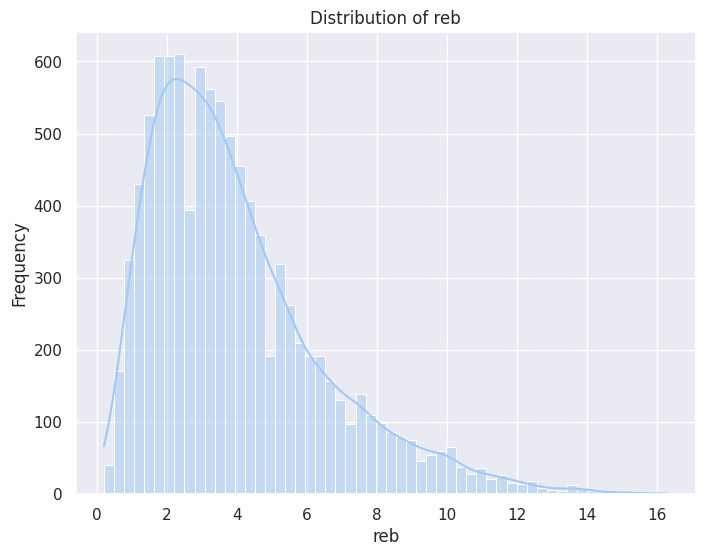

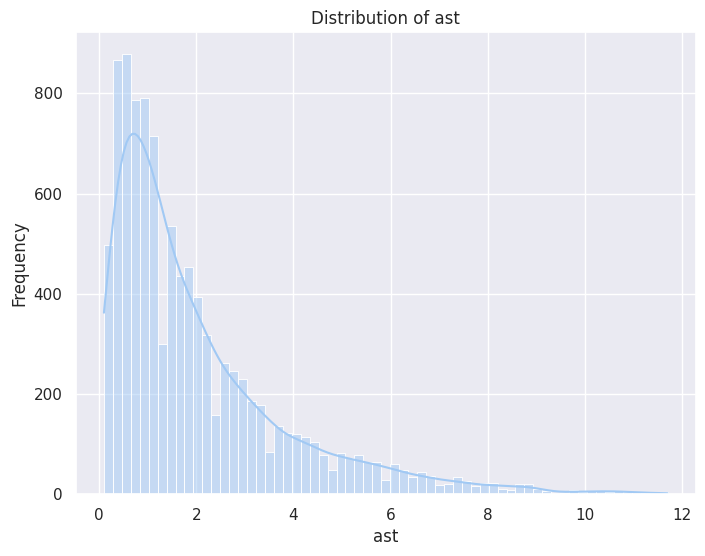

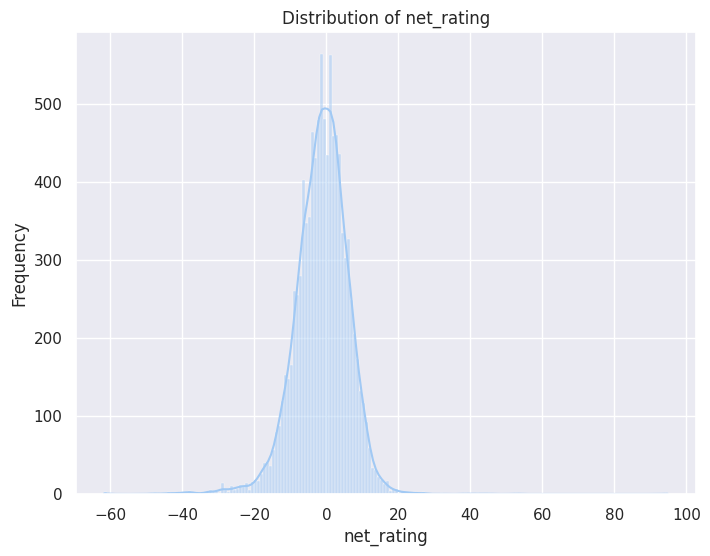

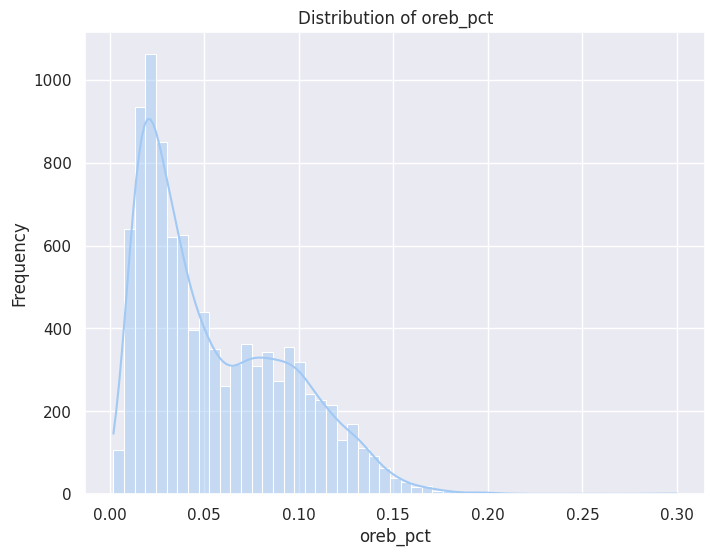

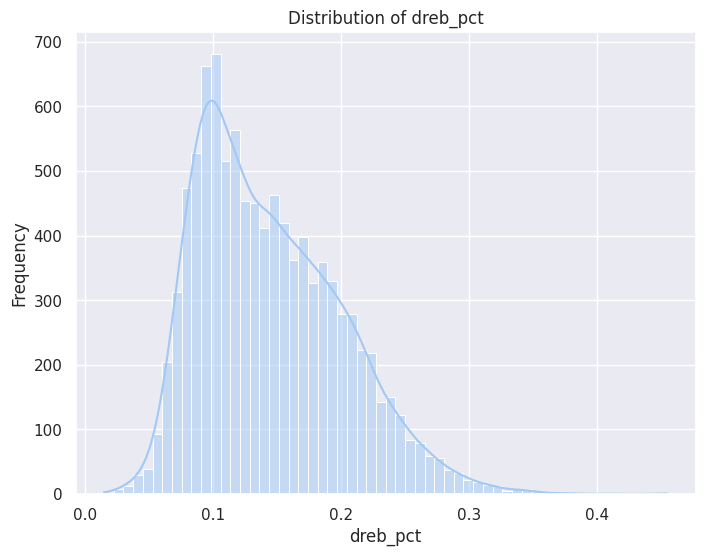

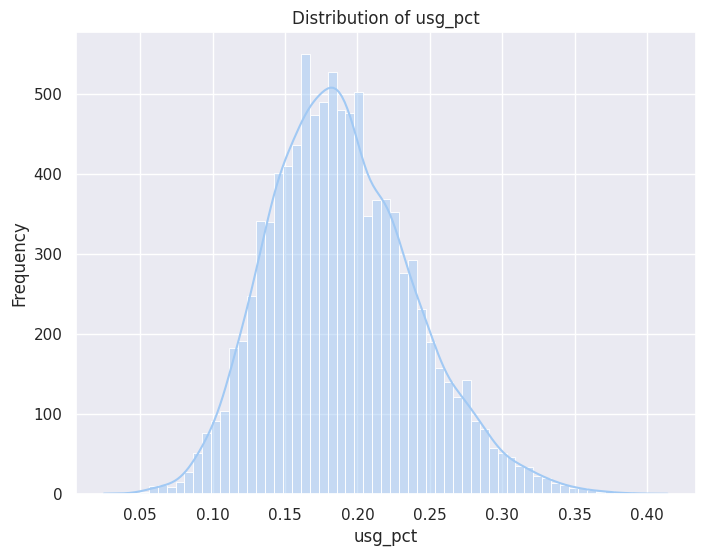

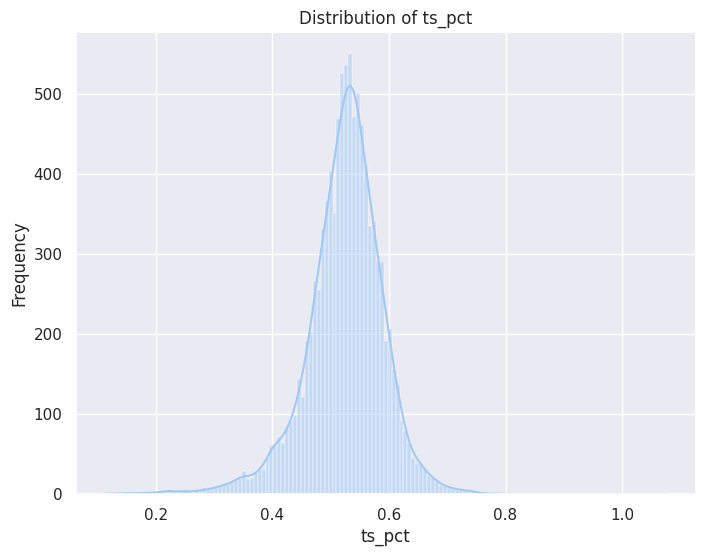

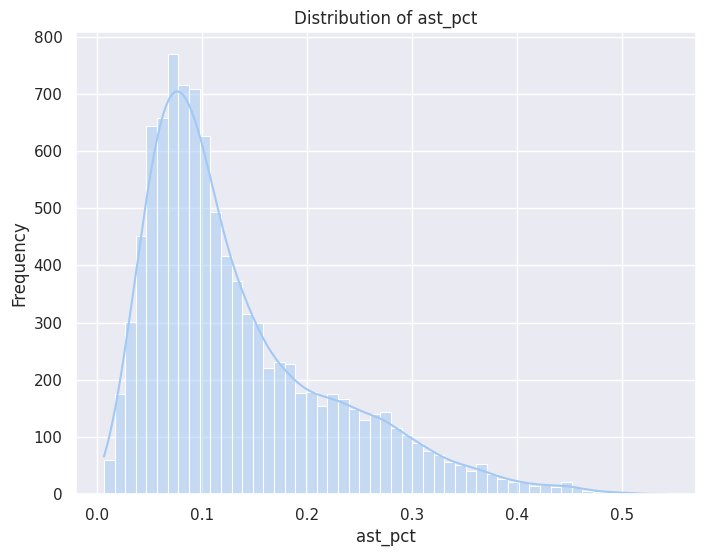

In [ ]:
numerical_cols = data.select_dtypes(include=['float64', 'int64']).columns
sns.set(style="darkgrid")
sns.set_palette("pastel")
# Create histograms with distribution lines
for col in numerical_cols:
    plt.figure(figsize=(8, 6))
    sns.histplot(data[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

In [ ]:
data.describe()

,age,player_height,player_weight,draft_year,draft_round,draft_number,gp,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct
count,9952.000000,9952.000000,9952.000000,9952.000000,9952.000000,9952.000000,9952.000000,9952.000000,9952.000000,9952.000000,9952.000000,9952.000000,9952.000000,9952.000000,9952.000000,9952.000000
mean,27.050241,201.214254,101.084353,2003.995378,1.292303,21.442625,56.542404,9.315715,3.979753,2.028889,-1.274970,0.055390,0.144727,0.189450,0.524358,0.134595
std,4.470977,8.874580,12.295935,8.950100,0.500496,15.904003,21.730353,6.128123,2.499688,1.878550,7.400846,0.038588,0.056228,0.050144,0.067585,0.089077
min,18.000000,160.020000,60.327736,1963.000000,1.000000,1.000000,1.000000,0.100000,0.200000,0.100000,-61.800000,0.002000,0.015000,0.025000,0.111000,0.007000
25%,24.000000,195.580000,92.079176,1997.000000,1.000000,8.000000,42.000000,4.500000,2.100000,0.700000,-5.600000,0.023000,0.100000,0.154000,0.491000,0.070000
50%,26.000000,203.200000,100.697424,2004.000000,1.000000,18.000000,62.000000,7.900000,3.400000,1.400000,-0.900000,0.043000,0.136000,0.185000,0.529000,0.106000
75%,30.000000,208.280000,109.769264,2011.000000,2.000000,32.000000,75.000000,12.800000,5.200000,2.700000,3.400000,0.084000,0.183000,0.221000,0.564000,0.179000
max,44.000000,231.140000,155.582056,2022.000000,8.000000,165.000000,85.000000,36.100000,16.300000,11.700000,94.800000,0.300000,0.455000,0.414000,1.078000,0.543000


In [ ]:
data.isnull().sum()

,0
team_abbreviation,0
age,0
player_height,0
player_weight,0
college,1558
country,0
draft_year,0
draft_round,0
draft_number,0
gp,0


In [ ]:
obj_data=data.loc[:,['team_abbreviation','college','country','season']]
data.drop(columns=['team_abbreviation','college','country','season'],inplace=True)

#obj_data=pd.get_dummies(obj_data,prefix='fet')
#obj_data=obj_data.replace({False:0,True:1})

X=data.drop(columns=['pts'])
y=data['pts']
X.head()

,age,player_height,player_weight,draft_year,draft_round,draft_number,gp,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct
0,22.0,193.04,94.800728,1996,2,42,64,1.5,2.4,0.3,0.042,0.071,0.169,0.487,0.248
1,28.0,190.50,86.182480,1994,2,34,4,1.3,0.3,8.9,0.030,0.111,0.174,0.497,0.043
2,26.0,203.20,103.418976,1993,1,12,41,6.4,1.9,-8.2,0.106,0.185,0.175,0.512,0.125
3,30.0,203.20,102.058200,1989,1,7,64,2.8,1.7,-2.7,0.027,0.111,0.206,0.527,0.125
4,23.0,213.36,119.748288,1995,1,22,52,1.7,0.3,-14.1,0.102,0.169,0.195,0.500,0.064


In [ ]:
sfs = SequentialFeatureSelector(
    LinearRegression(),
    k_features=(1, X.shape[1]),
    forward=True,
    floating=True,
    scoring='r2',
    cv=5,
    n_jobs=-1,
)
sfs.fit(X, y)
selected_features = list(sfs.k_feature_names_)
print(selected_features)
X=X[selected_features]

['age', 'draft_round', 'draft_number', 'gp', 'reb', 'ast', 'oreb_pct', 'dreb_pct', 'usg_pct', 'ts_pct', 'ast_pct']


In [ ]:
X.head()

,age,draft_round,draft_number,gp,reb,ast,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct
0,22.0,2,42,64,1.5,2.4,0.042,0.071,0.169,0.487,0.248
1,28.0,2,34,4,1.3,0.3,0.030,0.111,0.174,0.497,0.043
2,26.0,1,12,41,6.4,1.9,0.106,0.185,0.175,0.512,0.125
3,30.0,1,7,64,2.8,1.7,0.027,0.111,0.206,0.527,0.125
4,23.0,1,22,52,1.7,0.3,0.102,0.169,0.195,0.500,0.064


In [ ]:
obj_data.head()

,team_abbreviation,college,country,season
0,HOU,Louisiana State,USA,1996-97
1,WAS,Northwestern Oklahoma,USA,1996-97
2,VAN,North Carolina,USA,1996-97
3,LAL,Florida State,USA,1996-97
4,DEN,UCLA,USA,1996-97


In [ ]:
country_counts = obj_data['country'].value_counts()
filtered_counts = country_counts[country_counts > 50]
print(filtered_counts)

country
USA          8263
France        169
Canada        159
Spain          78
Brazil         74
Slovenia       73
Turkey         73
Croatia        65
Australia      60
Lithuania      58
Serbia         55
Name: count, dtype: int64


In [ ]:
college_counts = obj_data['college'].value_counts()
filtered_counts1 = college_counts[college_counts > 100]
print(filtered_counts1)

college
Kentucky           388
Duke               359
North Carolina     325
UCLA               273
Arizona            261
Kansas             259
Connecticut        208
Michigan           169
Georgia Tech       153
Florida            152
Michigan State     146
Syracuse           135
Georgetown         134
Texas              127
Maryland           127
Stanford           117
Wake Forest        114
Villanova          112
Indiana            111
Washington         106
Louisiana State    106
Memphis            105
Name: count, dtype: int64


In [ ]:
country_counts = obj_data['country'].value_counts()
countries_to_keep = country_counts[country_counts > 50].index
obj_data['country'] = obj_data['country'].apply(lambda x: x if x in countries_to_keep else 'Other')

college_counts = obj_data['college'].value_counts(dropna=False)
colleges_to_keep = college_counts[college_counts > 100].index
obj_data['college'] = obj_data['college'].apply(lambda x: x if x in colleges_to_keep else 'other')
obj_data['college'] = obj_data['college'].fillna('other').apply(lambda x: x if x in colleges_to_keep else 'other')

In [ ]:
obj_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9952 entries, 0 to 9951
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   team_abbreviation  9952 non-null   object
 1   college            9952 non-null   object
 2   country            9952 non-null   object
 3   season             9952 non-null   object
dtypes: object(4)
memory usage: 311.1+ KB


In [ ]:
obj_data=pd.get_dummies(obj_data,prefix='fet')
obj_data=obj_data.replace({False:0,True:1})
obj_data.drop(columns=['fet_other', 'fet_Other'],inplace=True)

<ipython-input-69-e5827137b8ac>:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  obj_data=obj_data.replace({False:0,True:1})


In [ ]:
obj_data.head()

,fet_ATL,fet_BKN,fet_BOS,fet_CHA,fet_CHH,fet_CHI,fet_CLE,fet_DAL,fet_DEN,fet_DET,...,fet_2013-14,fet_2014-15,fet_2015-16,fet_2016-17,fet_2017-18,fet_2018-19,fet_2019-20,fet_2020-21,fet_2021-22,fet_2022-23
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
import statsmodels.api as sm

X=pd.concat([X,obj_data],axis=1) # (9952,107)

x = X
x = sm.add_constant(x)
model = sm.OLS(y, x).fit()
model.summary()

# R2=0.926 , Adj. R2=0.925

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    pts   R-squared:                       0.926
Model:                            OLS   Adj. R-squared:                  0.925
Method:                 Least Squares   F-statistic:                     1166.
Date:                Tue, 03 Dec 2024   Prob (F-statistic):               0.00
Time:                        06:49:05   Log-Likelihood:                -19235.
No. Observations:                9952   AIC:                         3.868e+04
Df Residuals:                    9846   BIC:                         3.945e+04
Df Model:                         105                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -8.8279      0.216    -40.884      0.000      -9.251      -8.405
age                     0.0300      0.004      7.382      0.000       0.022       0.038
draft_round             0.4362      0.068      6.449      0.000       0.304       0.569
draft_number           -0.0147      0.002     -6.546      0.000      -0.019      -0.010
gp                      0.0084      0.001      8.204      0.000       0.006       0.010
reb                     1.1505      0.014     82.296      0.000       1.123       1.178
ast                     1.7511      0.025     69.971      0.000       1.702       1.800
oreb_pct              -24.1416      0.710    -33.979      0.000     -25.534     -22.749
dreb_pct              -23.1332      0.570    -40.605      0.000     -24.250     -22.016
usg_pct                60.7410      0.419    144.889      0.000      59.919      61.563
ts_pct                 11.5002      0.299     38.453      0.000      10.914      12.086
ast_pct               -27.8410      0.485    -57.421      0.000     -28.791     -26.891
fet_ATL                -0.2544      0.092     -2.751      0.006      -0.436      -0.073
fet_BKN                -0.3145      0.138     -2.286      0.022      -0.584      -0.045
fet_BOS                -0.1177      0.091     -1.290      0.197      -0.297       0.061
fet_CHA                -0.4160      0.109     -3.814      0.000      -0.630      -0.202
fet_CHH                -0.4435      0.209     -2.124      0.034      -0.853      -0.034
fet_CHI                -0.3020      0.095     -3.170      0.002      -0.489      -0.115
fet_CLE                -0.2672      0.094     -2.853      0.004      -0.451      -0.084
fet_DAL                -0.3702      0.097     -3.833      0.000      -0.559      -0.181
fet_DEN                -0.1569      0.092     -1.703      0.089      -0.337       0.024
fet_DET                -0.3439      0.095     -3.604      0.000      -0.531      -0.157
fet_GSW                -0.1446      0.094     -1.542      0.123      -0.328       0.039
fet_HOU                -0.1834      0.095     -1.937      0.053      -0.369       0.002
fet_IND                -0.3382      0.091     -3.716      0.000      -0.517      -0.160
fet_LAC                -0.3791      0.090     -4.216      0.000      -0.555      -0.203
fet_LAL                -0.0097      0.091     -0.107      0.915      -0.188       0.168
fet_MEM                -0.3122      0.100     -3.112      0.002      -0.509      -0.116
fet_MIA                -0.5842      0.098     -5.954      0.000      -0.777      -0.392
fet_MIL                -0.0903      0.091     -0.989      0.323      -0.269       0.089
fet_MIN                -0.2180      0.091     -2.391      0.017      -0.397      -0.039
fet_NJN                -0.0318      0.114     -0.279      0.781      -0.255       0.192
fet

In [ ]:
p_values = model.pvalues

# Create a list of features to remove
features_to_remove = []
for feature, p_value in p_values.items():
    if p_value > 0.05 and feature != 'const':
        features_to_remove.append(feature)

X = X.drop(columns=features_to_remove) # (9952,70)

In [ ]:
x = X
x = sm.add_constant(x)  # Use sm.add_constant directly
model = sm.OLS(y, x).fit()
model.summary()
# R2=0.925 , Adj. R2=0.925

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    pts   R-squared:                       0.925
Model:                            OLS   Adj. R-squared:                  0.925
Method:                 Least Squares   F-statistic:                     1751.
Date:                Tue, 03 Dec 2024   Prob (F-statistic):               0.00
Time:                        06:56:35   Log-Likelihood:                -19246.
No. Observations:                9952   AIC:                         3.863e+04
Df Residuals:                    9881   BIC:                         3.915e+04
Df Model:                          70                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -9.1039      0.224    -40.648      0.000      -9.543      -8.665
age                     0.0297      0.004      7.406      0.000       0.022       0.038
draft_round             0.4295      0.067      6.443      0.000       0.299       0.560
draft_number           -0.0149      0.002     -6.742      0.000      -0.019      -0.011
gp                      0.0083      0.001      8.307      0.000       0.006       0.010
reb                     1.1523      0.014     83.170      0.000       1.125       1.179
ast                     1.7508      0.025     70.378      0.000       1.702       1.800
oreb_pct              -24.2475      0.701    -34.577      0.000     -25.622     -22.873
dreb_pct              -23.1188      0.567    -40.806      0.000     -24.229     -22.008
usg_pct                60.6553      0.415    146.127      0.000      59.842      61.469
ts_pct                 11.5275      0.294     39.221      0.000      10.951      12.104
ast_pct               -27.8817      0.482    -57.818      0.000     -28.827     -26.936
fet_ATL                -0.1278      0.096     -1.334      0.182      -0.315       0.060
fet_BKN                -0.1983      0.141     -1.406      0.160      -0.475       0.078
fet_CHA                -0.2963      0.113     -2.633      0.008      -0.517      -0.076
fet_CHH                -0.3375      0.214     -1.575      0.115      -0.758       0.082
fet_CHI                -0.1876      0.099     -1.900      0.057      -0.381       0.006
fet_CLE                -0.1719      0.096     -1.782      0.075      -0.361       0.017
fet_DAL                -0.2525      0.100     -2.535      0.011      -0.448      -0.057
fet_DET                -0.2254      0.099     -2.285      0.022      -0.419      -0.032
fet_IND                -0.2385      0.094     -2.540      0.011      -0.423      -0.054
fet_LAC                -0.2730      0.093     -2.932      0.003      -0.455      -0.090
fet_MEM                -0.2089      0.103     -2.023      0.043      -0.411      -0.006
fet_MIA                -0.4725      0.101     -4.680      0.000      -0.670      -0.275
fet_MIN                -0.1106      0.095     -1.170      0.242      -0.296       0.075
fet_NYK                -0.2048      0.095     -2.154      0.031      -0.391      -0.018
fet_ORL                -0.1581      0.095     -1.670      0.095      -0.344       0.027
fet_PHX                -0.4393      0.097     -4.545      0.000      -0.629      -0.250
fet_POR                -0.0974      0.094     -1.033      0.302      -0.282       0.087
fet_SAS                -0.4498      0.096     -4.676      0.000      -0.638      -0.261
fet_Connecticut         0.3114      0.120      2.595      0.009       0.076       0.547
fet_Duke                0.2863      0.092      3.095      0.002       0.105       0.468
fet

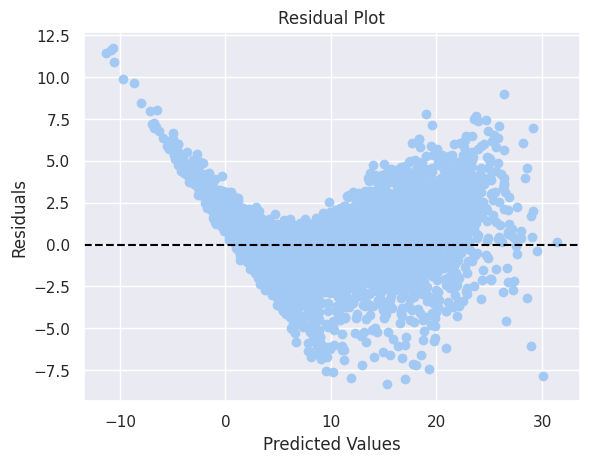

In [ ]:
lr = LinearRegression()
lr.fit(X, y)
y_pred = lr.predict(X)
res=y-y_pred

plt.scatter(y_pred,res)
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

In [ ]:
scaler = StandardScaler()
for col in X.columns:
    X[col] = scaler.fit_transform(X[[col]])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=162)

X.head()

,age,draft_round,draft_number,gp,reb,ast,oreb_pct,dreb_pct,usg_pct,ts_pct,...,fet_2011-12,fet_2012-13,fet_2013-14,fet_2014-15,fet_2015-16,fet_2016-17,fet_2017-18,fet_2018-19,fet_2020-21,fet_2021-22
0,-1.129618,1.414062,1.292656,0.343205,-0.992075,0.197562,-0.347009,-1.311273,-0.407838,-0.552781,...,-0.201957,-0.19788,-0.199246,-0.202495,-0.200063,-0.199519,-0.199519,-0.200876,-0.200605,-0.2033
1,0.212438,1.414062,0.789613,-2.418048,-1.072089,-0.920378,-0.657999,-0.599853,-0.308121,-0.404811,...,-0.201957,-0.19788,-0.199246,-0.202495,-0.200063,-0.199519,-0.199519,-0.200876,-0.200605,-0.2033
2,-0.234914,-0.584056,-0.593756,-0.715275,0.968268,-0.068614,1.311603,0.716274,-0.288178,-0.182858,...,-0.201957,-0.19788,-0.199246,-0.202495,-0.200063,-0.199519,-0.199519,-0.200876,-0.200605,-0.2033
3,0.659790,-0.584056,-0.908158,0.343205,-0.471984,-0.175085,-0.735747,-0.599853,0.330069,0.039096,...,-0.201957,-0.19788,-0.199246,-0.202495,-0.200063,-0.199519,-0.199519,-0.200876,-0.200605,-0.2033
4,-0.905942,-0.584056,0.035048,-0.209045,-0.912061,-0.920378,1.207940,0.431706,0.110691,-0.360421,...,-0.201957,-0.19788,-0.199246,-0.202495,-0.200063,-0.199519,-0.199519,-0.200876,-0.200605,-0.2033


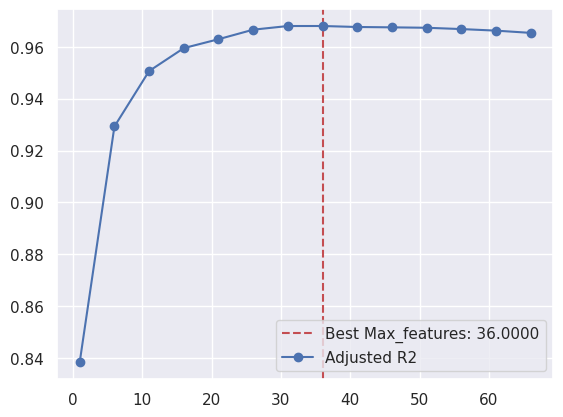

In [ ]:
## Optimizing RandomForestRegressor max_features
fet_vals=range(1,70,5)
adj_r2_scores=[]
for i in fet_vals:
  RF_car = RFR(max_features=i,
            random_state=0).fit(X_train, y_train)
  y_pred = RF_car.predict(X_test)
  r2=r2_score(y_test, y_pred)
  adj_r2_scores.append(1-(((1-r2)*(len(X_test)-1))/(len(X_test)-X_test.shape[1]-1)))

best_K = fet_vals[np.argmax(adj_r2_scores)]

plt.axvline(best_K, color='r', linestyle='--', label=f'Best Max_features: {best_K:.4f}')
plt.plot(fet_vals, adj_r2_scores,marker='o', label='Adjusted R2',color='b')
plt.legend()

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_distributions = {
    'n_estimators': [50,100,200,300],
    'max_depth': [None, 5,10],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [1,2],
}


rf = RandomForestRegressor(max_features=36,random_state=162)

random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_distributions,
                                   n_iter=15, scoring='r2',
                                   cv=3, n_jobs=-1, verbose=2, random_state=42)

random_search.fit(X_train, y_train)

print("Best parameters:", random_search.best_params_)
print("Best score:", random_search.best_score_)

# Get the best model
best_rf_model = random_search.best_estimator_

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best parameters: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': None}
Best score: 0.9641161271360693


In [ ]:
feature_imp = pd.DataFrame(
    {'importance': best_rf_model.feature_importances_},
    index=X_train.columns
)

top_10_features = feature_imp.sort_values(by='importance', ascending=False).head(10)
print(top_10_features)

              importance
usg_pct         0.426137
ast             0.216700
reb             0.201051
ts_pct          0.050374
gp              0.029402
ast_pct         0.022346
dreb_pct        0.018719
oreb_pct        0.014489
draft_number    0.008095
age             0.003656


In [ ]:
from sklearn.model_selection import GridSearchCV

# Ridge regression
ridge = Ridge()
param_grid_ridge = {'alpha': np.logspace(-4, 4, 10)}
grid_search_ridge = GridSearchCV(ridge, param_grid_ridge, scoring='r2', cv=5)
grid_search_ridge.fit(X_train, y_train)
print("Best Ridge alpha:", grid_search_ridge.best_params_)

# Lasso regression
lasso = Lasso()
param_grid_lasso = {'alpha': np.logspace(-4, 4, 10)}
grid_search_lasso = GridSearchCV(lasso, param_grid_lasso, scoring='r2', cv=10)
grid_search_lasso.fit(X_train, y_train)
print("Best Lasso alpha:", grid_search_lasso.best_params_)

Best Ridge alpha: {'alpha': 2.782559402207126}
Best Lasso alpha: {'alpha': 0.000774263682681127}


In [ ]:
#Optimizing ElasticNet
param_distributions = {
    'alpha': np.logspace(-5, 5, 100),
    'l1_ratio': np.arange(0, 1, 0.01)
}

elastic_net = ElasticNet()

random_search = RandomizedSearchCV(
    estimator=elastic_net,
    param_distributions=param_distributions,
    n_iter=100,
    scoring='r2',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)
print("Best parameters:", random_search.best_params_)
print("Best score:", random_search.best_score_)

best_EN_model = random_search.best_estimator_

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best parameters: {'l1_ratio': 0.62, 'alpha': 0.001047615752789665}
Best score: 0.9234916792622464


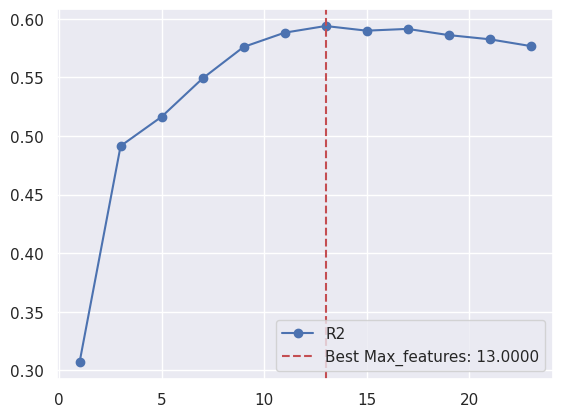

In [ ]:
#Optimizing KNN Regressor n_neighbors
from sklearn.neighbors import KNeighborsRegressor
fet_vals=range(1,25,2)
r2_scores=[]
for i in fet_vals:
  knn_model = KNeighborsRegressor(n_neighbors=i).fit(X_train, y_train)
  y_pred = knn_model.predict(X_test)
  r2_scores.append(r2_score(y_test, y_pred))

best_K = fet_vals[np.argmax(r2_scores)]

plt.plot(fet_vals, r2_scores,marker='o', label='R2',color='b')
plt.axvline(best_K, color='r', linestyle='--', label=f'Best Max_features: {best_K:.4f}')
plt.legend()

In [ ]:
!pip install xgboost
from xgboost import XGBRegressor
xgb = XGBRegressor(objective='reg:squarederror', random_state=162)

param_dist = {
    'n_estimators': np.arange(1, 200, 25),
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_child_weight': [1, 5, 10],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1, 0.5],
    'reg_alpha': [0, 0.1, 1.0],
    'reg_lambda': [0, 0.1, 1.0],
    'tree_method': ['auto', 'gpu_hist']
}


random_search = RandomizedSearchCV(xgb, param_dist, n_iter=50, cv=5, scoring='r2', n_jobs=-1)
random_search.fit(X_train, y_train)

print(f"Best parameters: {random_search.best_params_}")
print(f"Best R^2 score: {random_search.best_score_}")


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
120 fits failed out of a total of 250.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/xgboost/core.py", line 726, in inner_f
    return func(**kwargs)
  File "/usr/local/lib/python3.10/dist-packages/xgboost/sklearn.py", line 1108, in fit
    self._Booster = train(
  File "/usr/local/lib/python3.10/dist-packages/xgboost/core.py", line 726, in inner_f
 

Best parameters: {'tree_method': 'auto', 'subsample': 0.8, 'reg_lambda': 0.1, 'reg_alpha': 1.0, 'n_estimators': 176, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 1.0}
Best R^2 score: 0.9835973729471581


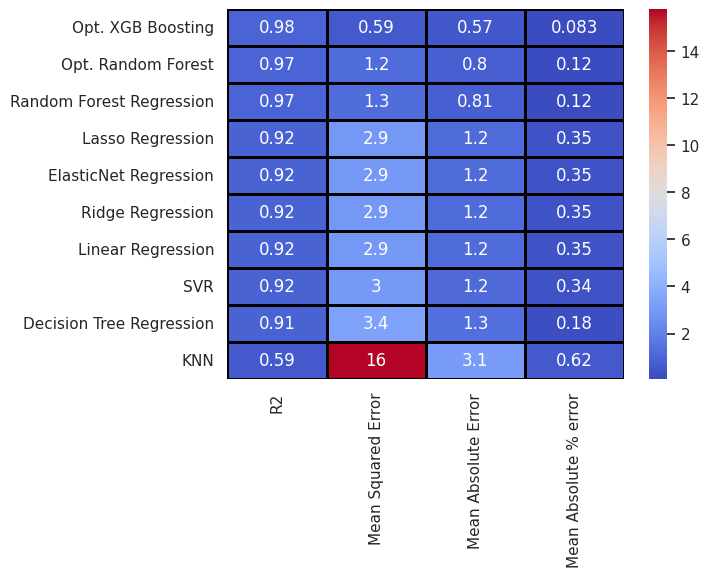

In [ ]:
model_dic = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=2.78),
    "Lasso Regression": Lasso(alpha=0.00077),
    "ElasticNet Regression": best_EN_model,
    "Decision Tree Regression": DTR(),
    "Random Forest Regression": RFR(),
    "Opt. Random Forest": best_rf_model,
    "SVR": SVR(kernel='linear'),
    "Opt. XGB Boosting": XGBRegressor(n_estimators=176,tree_method='auto',subsample=0.8,reg_lambda=0.1,reg_alpha=1.0,min_child_weight=1,max_depth=5,learning_rate=0.1,gamma=0.1,colsample_bytree=1.0),
    "KNN": KNeighborsRegressor(n_neighbors=13),
}

metric_dic={}

for (i, model) in model_dic.items():
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)

    metric_dic[i]={'R2':r2_score(y_test,y_pred),
                "Mean Squared Error"  :mean_squared_error(y_test,y_pred),
                "Mean Absolute Error"  :mean_absolute_error(y_test,y_pred),
                "Mean Absolute % error"  :mean_absolute_percentage_error(y_test, y_pred)}

metric_dic=pd.DataFrame(metric_dic)
metric_dic_transposed = metric_dic.T
metric_dic_sorted = metric_dic_transposed.sort_values(by=['R2'],ascending=False)

sns.heatmap(metric_dic_sorted, cmap="coolwarm", annot=True, linecolor="black", linewidths=1)
plt.show()